In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn


Notebook is working


In [ ]:
df = pd.read_csv('../data/dataset.csv')

df = df.drop(columns=["Unnamed: 0"])

Rows and columns: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [11]:
target = "popularity"

features = [
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
    "track_genre"
]

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (114000, 15)
y shape: (114000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
    )
    
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 91200
Testing rows: 22800


In [13]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# StandardScaler:
# Makes number columns easier for regression models to work with.

# OneHotEncoder:
# Turns track_genre into numeric columns.
# Example: pop, rap, rock, country become separate 0/1 columns.

# ColumnTransformer:
# Applies the right preprocessing to the right columns.

# Pipeline:
# Lets us combine preprocessing and the ML model into one clean object.

numeric_features = [
    "duration_ms",
    "danceability",
    "energy",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature"
]

categorical_features = [
    "explicit",
    "track_genre"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [14]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [15]:
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    return {
        "Model" : model_name,
        "MAE" : mae,
        "MSE" : mse,
        "RMSE" : rmse,
        "R2 Score" : r2
    }

results = []
results.append(evaluate_model(linear_model, X_test, y_test, "Linear Regression"))
results.append(evaluate_model(ridge_model, X_test, y_test, "Ridge Regression"))
results.append(evaluate_model(random_forest_model, X_test, y_test, "Random Forest"))

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,14.084492,365.762050,19.124907,0.258812
1,Ridge Regression,14.087077,365.762342,19.124914,0.258812
2,Random Forest,10.314750,233.942003,15.295163,0.525935


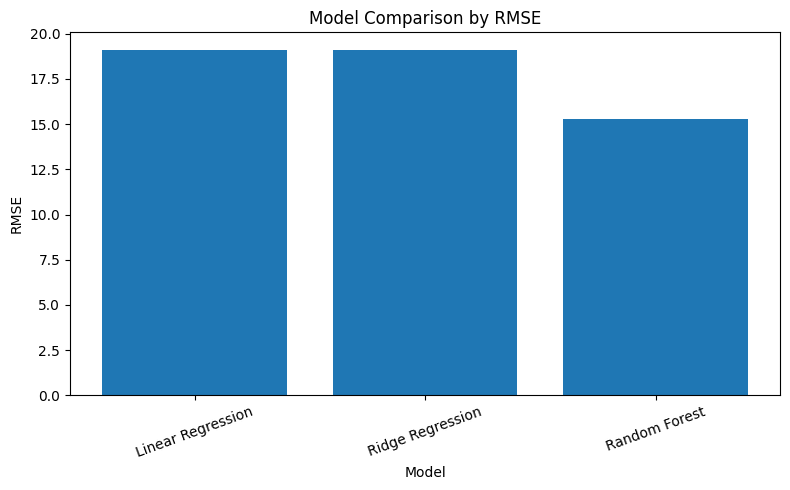

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

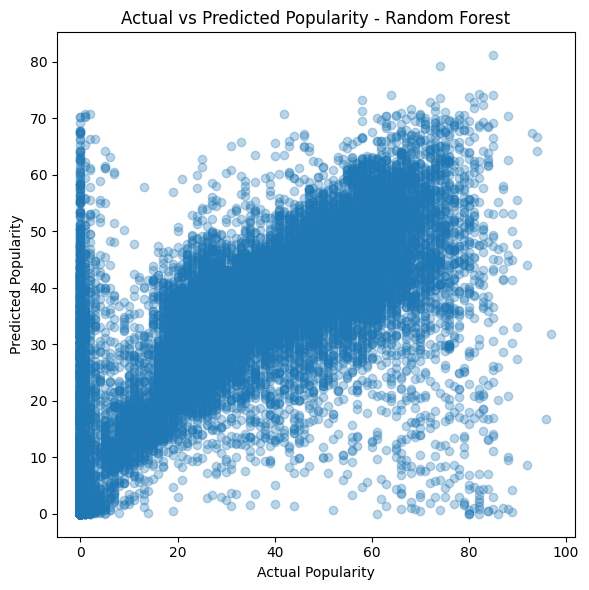

In [22]:
rf_predictions = random_forest_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_predictions, alpha=0.3)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted Popularity - Random Forest")
plt.tight_layout()
plt.show()